In [ ]:
import sys

sys.path.append("../")

import numpy as np

from qiskit.circuit import ClassicalRegister, Parameter, QuantumCircuit, QuantumRegister
from qiskit.transpiler import generate_preset_pass_manager
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator

from dicke_state_ansatz import DickeStateAnsatz

In [2]:
simulator = AerSimulator(method="statevector", device="GPU")
pm = generate_preset_pass_manager(backend=simulator, optimization_level=0)

## Pure state

In [3]:
n = 4
k = 1

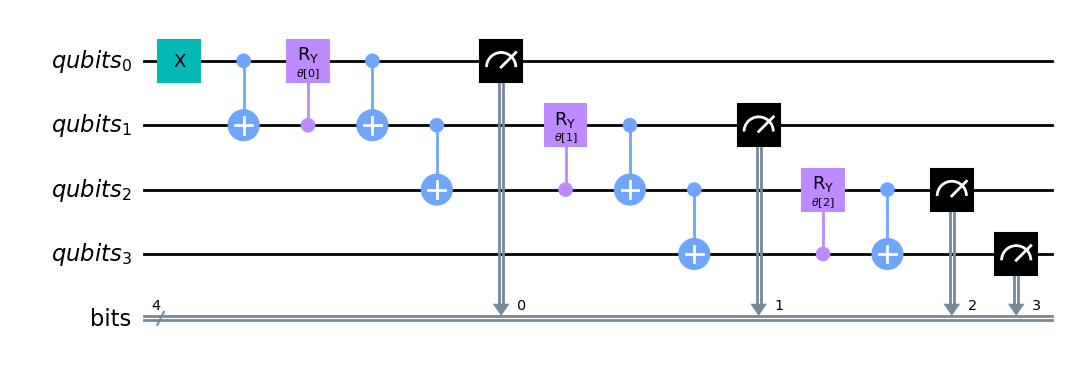

In [4]:
qc = DickeStateAnsatz().generate_quantum_circuit(n=n, k=k)

qc.draw(output="mpl", style="clifford")

In [5]:
params_mapping = {param: np.pi/2 for param in qc.parameters}
qc = qc.assign_parameters(parameters=params_mapping)

In [6]:
counts = simulator.run(circuits=qc, shots=4096).result().get_counts()

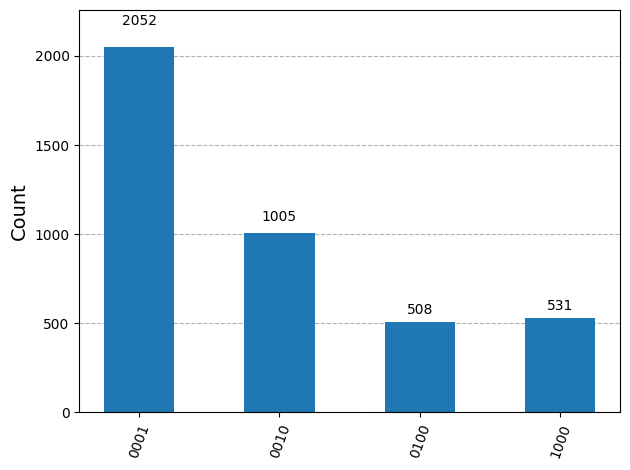

In [7]:
plot_histogram(data=counts)

## Mixture

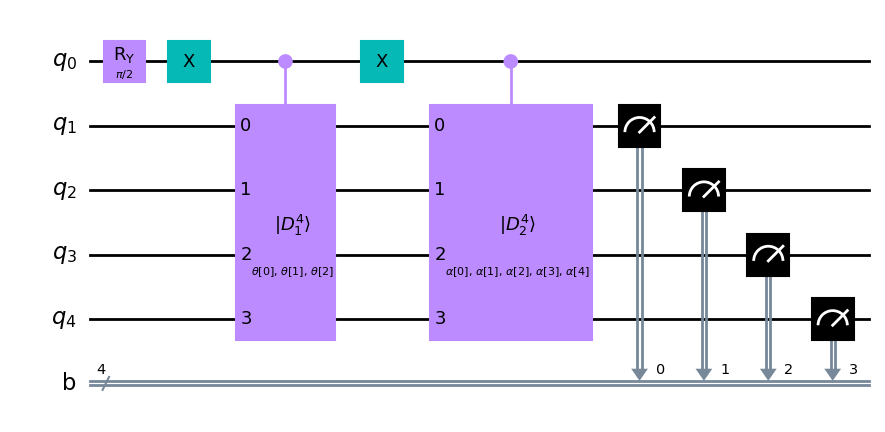

In [8]:
qubits = QuantumRegister(size=5, name="q")
bits = ClassicalRegister(size=n, name="b")

qc = QuantumCircuit(qubits, bits)
qc.ry(theta=np.pi/2, qubit=qubits[0])

params_names = {1: "theta", 2: "alpha"}

for k in range(1,3):
    dicke = DickeStateAnsatz().generate_quantum_circuit(n=n, k=k, measurement=False, param_name=params_names[k])
    if k == 1:
        qc.x(qubit=qubits[0])
    dicke_gate = dicke.to_gate(label=rf"$\vert D^{n}_{k} \rangle$").control(1)
    qc.append(dicke_gate, qargs=range(qubits.size))
    if k == 1:
        qc.x(qubit=qubits[0])

qc.measure(qubit=qubits[1:], cbit=bits)
qc.draw(output="mpl", style="clifford")

In [9]:
params_mapping = {param: np.pi/2 for param in qc.parameters}
qc = qc.assign_parameters(parameters=params_mapping)

In [10]:
pm = generate_preset_pass_manager(backend=simulator, optimization_level=0)
tqc = pm.run(qc)

In [11]:
counts = simulator.run(circuits=tqc, shots=4096).result().get_counts()

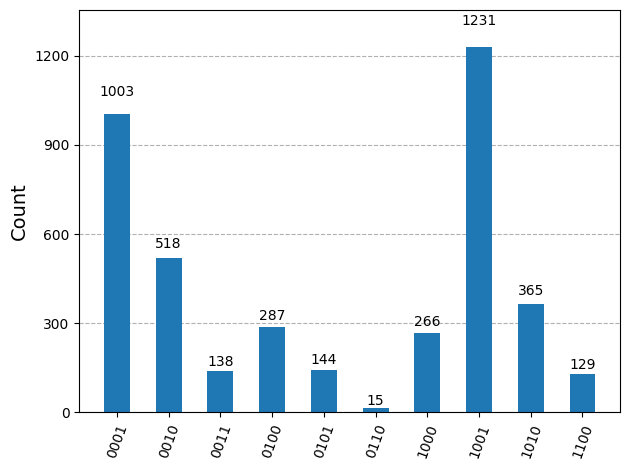

In [12]:
plot_histogram(data=counts)